# **Introduction to Diffusion Models for Text-to-Image Generation**

---

### **<p style="text-align: center; text-decoration: underline;">Introduction to Diffusion Models</p>**
# **<p style="text-align: center;">Text-to-Image Generation with Diffusion Models</p>**

---

> Tutor: *Omar IKNE*

> Master, IMT Nord Europe

---

### ■ **Overview**

In this notebook, we will explore the fascinating world of diffusion models for text-to-image generation. Diffusion models have revolutionized image generation by learning to reverse a gradual noising process, creating highly realistic images from random noise. We'll build a simple diffusion model from scratch and train it on a small dataset to understand the fundamental concepts.

**Main Task: Text-to-Image Generation**

![Diffusion Process](https://imgs.search.brave.com/HQ6f8BLM8vHBXJWwYv7MdMbq6ddhGU-pZOKWQnYCP58/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9pbWFn/ZXMucHJpc21pYy5p/by9lbmNvcmQvZjAz/ZWQ5OWItOTBkMi00/NDQxLTg1MzctYThh/YTBhZjIzMjQ2X2lt/YWdlMTIucG5nP2F1/dG89Y29tcHJlc3Ms/Zm9ybWF0)

### ■ **Contents**

- [1. Preliminaries](#section1)
- [2. Understanding Diffusion Models](#section2)
- [3. Dataset Preparation](#section3)
- [4. Building the Diffusion Model](#section4)
- [5. Training the Model](#section5)
- [6. Text-to-Image Generation](#section6)
- [7. Model Evaluation](#section7)

---

### ■ **Libraries**

In [12]:
# Install required packages
# !pip install torch torchvision matplotlib pillow tqdm numpy
!pip install datasets transformers

In [13]:
# Import dependencies
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid


import os
import zipfile
import urllib.request
import random
from pathlib import Path
from collections import defaultdict

from torchvision import transforms
from PIL import Image
import textwrap
from transformers import CLIPTokenizer, CLIPTextModelWithProjection
from transformers import AutoTokenizer, AutoModel

# Basic dependencies
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from tqdm import tqdm
from copy import deepcopy
from datasets import load_dataset

# Set random seeds for reproducibility
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()


### ■ **<a name="section1">1. Preliminaries</a>** [(&#8593;)](#content)

Diffusion models are a class of generative models that have shown remarkable performance in image generation tasks. The core idea is to learn a process that gradually transforms random noise into realistic images.

#### **Key Concepts:**

1. **Forward Process (Diffusion):** Gradually add noise to an image until it becomes pure Gaussian noise
2. **Reverse Process (Denoising):** Learn to reverse the noise addition process to generate images from noise
3. **Noise Schedule:** Controls how much noise is added at each step
4. **Text Conditioning:** Using text prompts to guide the image generation process

#### **Mathematical Foundation:**

The diffusion process can be described as a Markov chain:
- Forward: $q(x_t|x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}x_{t-1}, \beta_t I)$
- Reverse: $p_\theta(x_{t-1}|x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$

Where $\beta_t$ is the noise schedule and $\theta$ represents the model parameters.

---

### ■ **<a name="section2">2. Understanding Diffusion Models</a>** [(&#8593;)](#content)

Let's first understand the core concepts through implementation before building our complete model.

#### **Question 1: What is the forward diffusion process?**

The forward process gradually adds Gaussian noise to an image over multiple timesteps.


In [14]:
import requests

def download_image(image_url, file_dir):
    response = requests.get(image_url)
    if response.status_code == 200:
        directory = os.path.dirname(file_dir)
        if not os.path.exists(directory):
            os.makedirs(directory)
        with open(file_dir, "wb") as fp:
            fp.write(response.content)
        print("Image downloaded successfully.")
    else:
        print(f"Failed to download the image. Status code: {response.status_code}")

# Download an example image
image_url = "https://img-9gag-fun.9cache.com/photo/aPg3MoB_460s.jpg"
file_dir = "./image.jpg"
download_image(image_url, file_dir)

Image downloaded successfully.


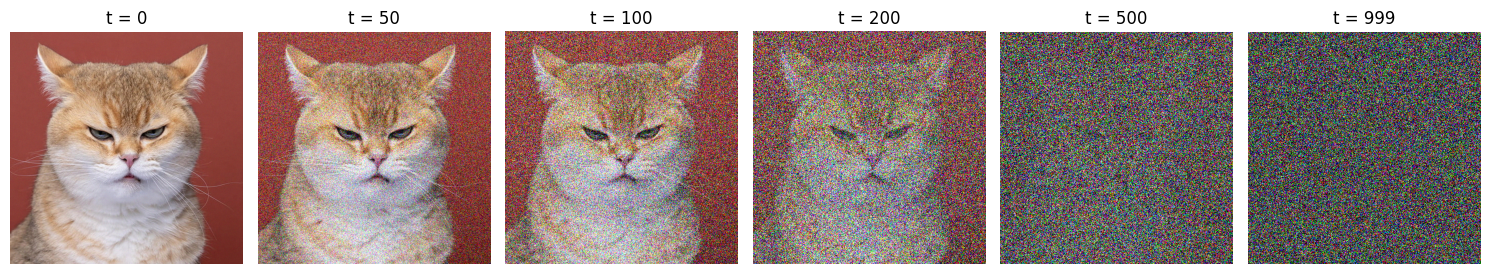

In [15]:
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    """Linear noise schedule for the diffusion process"""
    return torch.linspace(start, end, timesteps)

def forward_diffusion_sample(x_0, t, betas, device="cpu"):
    """
    Sample from q(x_t | x_0) using the reparameterization trick

    Args:
        x_0: Original image (batch_size, channels, height, width)
        t: Timestep (batch_size,)
        betas: Noise schedule (timesteps,)
        device: Device to run on

    Returns:
        x_t: Noisy image at timestep t
        noise: The noise that was added
    """
    # Extract sqrt(alpha_bar) and sqrt(1-alpha_bar) for timestep t
    t = t.to(device)
    sqrt_alphas_cumprod = torch.sqrt(1. - betas).cumprod(dim=0).to(device)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - sqrt_alphas_cumprod ** 2)

    # Gather the appropriate values for timestep t
    sqrt_alphas_cumprod_t = sqrt_alphas_cumprod[t].to(device)
    sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod[t].to(device)

    # Reshape for broadcasting
    sqrt_alphas_cumprod_t = sqrt_alphas_cumprod_t[:, None, None, None]
    sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod_t[:, None, None, None]

    # Sample noise
    noise = torch.randn_like(x_0).to(device)

    # Forward diffusion: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * epsilon
    x_t = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise

    return x_t, noise

# Let's test the forward diffusion process
def visualize_forward_process():
    """Visualize the forward diffusion process on a sample image"""
    # Load a sample image
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])

    # Use a sample image (you can replace this with any image)
    sample_image = torch.randn(1, 3, 64, 64)  # Random image for demonstration

    # Set up diffusion parameters
    timesteps = 1000
    betas = linear_beta_schedule(timesteps)

    # Select specific timesteps to visualize
    viz_timesteps = [0, 50, 100, 200, 500, 999]

    fig, axes = plt.subplots(1, len(viz_timesteps), figsize=(15, 3))

    for i, t in enumerate(viz_timesteps):
        x_t, noise = forward_diffusion_sample(sample_image, torch.tensor([t]), betas)

        # Denormalize for visualization
        img = x_t[0].permute(1, 2, 0)
        img = (img * 0.5 + 0.5).clamp(0, 1)

        axes[i].imshow(img)
        axes[i].set_title(f't = {t}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Let's test the forward diffusion process
def visualize_forward_process_image(image_path):
    """Visualize the forward diffusion process on a sample image"""
    # Load a sample image
    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])

    # Use a sample image (you can replace this with any image)
    sample_image = Image.open(image_path)
    sample_image = transforms.ToTensor()(sample_image)

    # Set up diffusion parameters
    timesteps = 1000
    betas = linear_beta_schedule(timesteps)

    # Select specific timesteps to visualize
    viz_timesteps = [0, 50, 100, 200, 500, 999]

    fig, axes = plt.subplots(1, len(viz_timesteps), figsize=(15, 3))

    for i, t in enumerate(viz_timesteps):
        x_t, noise = forward_diffusion_sample(sample_image, torch.tensor([t]), betas)

        # Denormalize for visualization
        img = x_t[0].permute(1, 2, 0)
        # img = (img * 0.5 + 0.5).clamp(0, 1)

        axes[i].imshow(img)
        axes[i].set_title(f't = {t}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# run the visualization
IMAGE_SIZE = 64
image_path = './image.jpg'
visualize_forward_process_image(image_path)

**Question 1.1:** What happens to the image as we increase the timestep `t`?

* We get better diversity because the model has more choices at each step.

**Question 1.2:** Why do we use a noise schedule instead of adding the same amount of noise at each step?

* The model would just have to denoise everything at once.

---

#### **Question 2: How does the reverse process work?**

The reverse process learns to denoise images. We train a neural network (e.g., UNet) to predict the noise that was added.


![unet](https://imgs.search.brave.com/8j6JTJDkvO2IMs_AyWG5Wb_3GFpUSkWXIHzoKc2YWX8/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9jZG4u/bGVhcm5vcGVuY3Yu/Y29tL3dwLWNvbnRl/bnQvdXBsb2Fkcy8y/MDIzLzAyLzA0MDkx/MjA4L2Rlbm9pc2lu/Zy1kaWZmdXNpb24t/cHJvYmFiaWxpc3Rp/Yy1tb2RlbHMtZm9y/d2FyZF9hbmRfYmFj/a3dhcmRfZXF1YXRp/b25zLnBuZw)


In [16]:
class SimpleUNet(nn.Module):
    """A simplified U-Net architecture for diffusion models"""

    def __init__(self, in_channels=3, out_channels=3, base_channels=64):
        super(SimpleUNet, self).__init__()

        # Encoder (Downsampling)
        self.enc1 = self._block(in_channels, base_channels)
        self.enc2 = self._block(base_channels, base_channels * 2)
        self.enc3 = self._block(base_channels * 2, base_channels * 4)

        # Bottleneck
        self.bottleneck = self._block(base_channels * 4, base_channels * 8)

        # Decoder (Upsampling)
        self.dec3 = self._block(base_channels * 12, base_channels * 4)  # Skip connection
        self.dec2 = self._block(base_channels * 6, base_channels * 2)   # Skip connection
        self.dec1 = self._block(base_channels * 3, base_channels)       # Skip connection

        # Final convolution
        self.final_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

        # Pooling and upsample
        self.pool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def _block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        bottleneck = self.bottleneck(self.pool(e3))

        # Decoder with skip connections
        d3 = self.dec3(torch.cat([self.upsample(bottleneck), e3], dim=1))
        d2 = self.dec2(torch.cat([self.upsample(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.upsample(d2), e1], dim=1))

        return self.final_conv(d1)

# Test the model
def test_unet():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleUNet(in_channels=3, out_channels=3, base_channels=IMAGE_SIZE).to(device)

    # Create a dummy input
    dummy_input = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)

    # Forward pass
    with torch.no_grad():
        output = model(dummy_input)

    print(f"Input shape: {dummy_input.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

test_unet()

Input shape: torch.Size([4, 3, 64, 64])
Output shape: torch.Size([4, 3, 64, 64])
Model parameters: 7,788,675



**Question 2.1:** What is the purpose of the U-Net architecture in diffusion models?

* It makes it possible to generate good-quality images quickly.

**Question 2.2:** Why are skip connections important in the U-Net architecture?

* To recover information lost during downsampling.
---

### ■ **<a name="section3">3. Dataset Preparation</a>** [(&#8593;)](#content)

We'll use a simple dataset for our text-to-image generation task. Let's use the [**FLICKR8K**](https://huggingface.co/datasets/jxie/flickr8k) dataset with simple text descriptions.

In [17]:
# ============================================================
# Flickr8k download + processing
# ============================================================
#
# Creates:
#
# data/
# └── Flickr8k/
#     ├── Flicker8k_Dataset/
#     │   ├── 1000268201_693b08cb0e.jpg
#     │   └── ...
#     │
#     ├── Flickr8k.token.txt
#     ├── Flickr_8k.trainImages.txt
#     ├── Flickr_8k.devImages.txt
#     └── Flickr_8k.testImages.txt
#
# Each image has 5 real human-written captions.
#
# Source:
# https://github.com/jbrownlee/Datasets/releases/tag/Flickr8k
#
# ============================================================

# ============================================================
# Configuration
# ============================================================

DATA_ROOT = Path("./data/Flickr8k")

BATCH_SIZE = 8
NUM_WORKERS = 2

RANDOM_CAPTION = True

# Download URLs
IMAGE_URL = ("https://github.com/jbrownlee/Datasets/releases/download/""Flickr8k/Flickr8k_Dataset.zip")
TEXT_URL = ("https://github.com/jbrownlee/Datasets/releases/download/""Flickr8k/Flickr8k_text.zip")


# ============================================================
# Download helper
# ============================================================

def download_file(url, destination):
    """
    Download a file with a simple progress indicator.
    """

    destination = Path(destination)

    if destination.exists():
        print(f"Already exists: {destination}")
        return

    print()
    print(f"Downloading:")
    print(f"  {url}")
    print(f"-> {destination}")

    destination.parent.mkdir(parents=True, exist_ok=True)

    urllib.request.urlretrieve(url, destination, reporthook=_download_progress,)

    print()
    print("Download complete.")


def _download_progress(block_num, block_size, total_size):
    """
    Progress callback for urllib.
    """

    if total_size <= 0:
        return

    downloaded = block_num * block_size
    downloaded = min(downloaded, total_size)

    percent = downloaded / total_size * 100

    print(
        f"\r  {percent:6.2f}% "
        f"({downloaded / 1024**2:.1f} / "
        f"{total_size / 1024**2:.1f} MB)",
        end="",
    )


# ============================================================
# ZIP extraction helper
# ============================================================

def extract_zip(zip_path, destination):
    """
    Extract ZIP archive if it has not already been extracted.
    """

    zip_path = Path(zip_path)
    destination = Path(destination)

    print()
    print(f"Extracting {zip_path.name} ...")

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(destination)

    print("Extraction complete.")


# ============================================================
# Find a file recursively
# ============================================================

def find_file(root, filename):
    """
    Find filename anywhere below root.
    """

    root = Path(root)

    matches = list(root.rglob(filename))

    if not matches:
        return None

    return matches[0]


# ============================================================
# Prepare Flickr8k
# ============================================================

def prepare_flickr8k(root=DATA_ROOT):
    """
    Download and extract Flickr8k.

    Returns:
        image_dir
        text_dir
    """

    root = Path(root)

    root.mkdir(parents=True, exist_ok=True)

    image_zip = root / "Flickr8k_Dataset.zip"
    text_zip = root / "Flickr8k_text.zip"

    # --------------------------------------------------------
    # Download
    # --------------------------------------------------------

    print("=" * 70)
    print("Downloading Flickr8k")
    print("=" * 70)

    download_file(IMAGE_URL, image_zip)
    download_file(TEXT_URL, text_zip)

    # --------------------------------------------------------
    # Extract
    # --------------------------------------------------------

    image_marker = find_file(root, "Flickr8k.token.txt")
    image_folder = find_file(root,"Flickr_8k.trainImages.txt")

    # Text archive
    if image_marker is None:
        extract_zip(text_zip, root)

    # Image archive
    image_dir = find_file(root,"Flicker8k_Dataset")

    if image_dir is None:
        extract_zip(image_zip, root)

    # --------------------------------------------------------
    # Locate files after extraction
    # --------------------------------------------------------

    image_dir = find_file(root, "Flicker8k_Dataset")

    token_file = find_file(root, "Flickr8k.token.txt")

    train_file = find_file(root,"Flickr_8k.trainImages.txt")
    val_file = find_file(root, "Flickr_8k.devImages.txt")
    test_file = find_file(root, "Flickr_8k.testImages.txt")

    # --------------------------------------------------------
    # Verify
    # --------------------------------------------------------

    required = {
        "image directory": image_dir,
        "caption file": token_file,
        "train split": train_file,
        "validation split": val_file,
        "test split": test_file,
    }

    missing = [name for name, path in required.items() if path is None]

    if missing:
        raise RuntimeError(
            "Flickr8k extraction failed.\n"
            "Missing:\n"
            + "\n".join(f"  - {x}" for x in missing)
        )

    print()
    print("=" * 70)
    print("Flickr8k is ready")
    print("=" * 70)

    print(f"Images:     {image_dir}")
    print(f"Captions:   {token_file}")
    print(f"Train:      {train_file}")
    print(f"Validation: {val_file}")
    print(f"Test:       {test_file}")

    # --------------------------------------------------------
    # Remove ZIP files to save disk space
    # --------------------------------------------------------

    for zip_file in (image_zip, text_zip):

        if zip_file.exists():
            print()
            print(f"Removing archive: {zip_file.name}")
            zip_file.unlink()

    return {
        "image_dir": image_dir,
        "token_file": token_file,
        "train_file": train_file,
        "val_file": val_file,
        "test_file": test_file,
    }


# ============================================================
# Flickr8k Dataset
# ============================================================

class Flickr8kDiffusionDataset(Dataset):
    """
    Flickr8k dataset for text-conditioned diffusion.

    Returns:

        image:   Tensor [3, image_size, image_size]
        caption: Human-written caption

    Each Flickr8k image has 5 captions.

    During training, one caption is randomly selected.
    """

    def __init__(
        self,
        image_dir,
        token_file,
        split_file,
        image_size=128,
        random_caption=True,
        train=False,
        center_crop=True,
        horizontal_flip=True,
    ):
        super().__init__()

        self.image_dir = Path(image_dir)
        self.random_caption = random_caption
        self.train = train

        # --------------------------------------------------------
        # Parse captions
        # --------------------------------------------------------

        self.captions = self._load_captions(token_file)

        # --------------------------------------------------------
        # Load split
        # --------------------------------------------------------

        self.image_names = self._load_split(split_file)

        # Only keep images for which captions exist
        self.image_names = [name for name in self.image_names if name in self.captions]

        if len(self.image_names) == 0:
            raise RuntimeError(
                "No images found.\n"
                f"Image directory: {self.image_dir}\n"
                f"Split file: {split_file}"
            )

        # --------------------------------------------------------
        # Image transforms
        # --------------------------------------------------------

        transform_list = [transforms.Resize(image_size, interpolation=transforms.InterpolationMode.BICUBIC,)]

        if center_crop:
            transform_list.append(transforms.CenterCrop(image_size))
        else:
            transform_list.append(transforms.Resize((image_size, image_size)))

        # Augmentation only for training
        if train and horizontal_flip:
            transform_list.append(transforms.RandomHorizontalFlip())

        transform_list.extend(
            [
                transforms.ToTensor(),
                # [0, 1] -> [-1, 1]
                transforms.Normalize(
                    mean=(0.5, 0.5, 0.5),
                    std=(0.5, 0.5, 0.5),
                ),
            ]
        )

        self.transform = transforms.Compose(transform_list)

        print(f"Loaded {len(self.image_names):,} images")

    # --------------------------------------------------------
    # Load captions
    # --------------------------------------------------------

    @staticmethod
    def _load_captions(token_file):

        captions = defaultdict(list)

        token_file = Path(token_file)

        with open(token_file, "r", encoding="utf-8") as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                # Format:
                #
                # image.jpg#0<TAB>caption

                parts = line.split("\t", 1)

                if len(parts) != 2:
                    continue

                image_id, caption = parts

                # Remove "#0", "#1", etc.
                image_name = image_id.split("#")[0]

                caption = caption.strip()

                if caption:
                    captions[image_name].append(caption)

        return dict(captions)

    # --------------------------------------------------------
    # Load split
    # --------------------------------------------------------

    @staticmethod
    def _load_split(split_file):
        split_file = Path(split_file)
        with open(split_file, "r", encoding="utf-8") as f:
            images = [line.strip() for line in f if line.strip()]
        return images

    # --------------------------------------------------------
    # Dataset interface
    # --------------------------------------------------------

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, index):

        image_name = self.image_names[index]

        image_path = self.image_dir / image_name

        # --------------------------------------------------------
        # Load image
        # --------------------------------------------------------

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        # --------------------------------------------------------
        # Select caption
        # --------------------------------------------------------

        captions = self.captions[image_name]

        if self.random_caption:
            caption = random.choice(captions)
        else:
            caption = captions[0]

        return image, caption


# ============================================================
# Download + prepare
# ============================================================

paths = prepare_flickr8k(DATA_ROOT)


Downloading:
  https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
-> data/Flickr8k/Flickr8k_Dataset.zip
  100.00% (1063.7 / 1063.7 MB)
Download complete.

Downloading:
  https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
-> data/Flickr8k/Flickr8k_text.zip
  100.00% (2.2 / 2.2 MB)
Download complete.

Flickr8k is ready
Images:     data/Flickr8k/Flicker8k_Dataset
Captions:   data/Flickr8k/Flickr8k.token.txt
Train:      data/Flickr8k/Flickr_8k.trainImages.txt
Validation: data/Flickr8k/Flickr_8k.devImages.txt
Test:       data/Flickr8k/Flickr_8k.testImages.txt

Removing archive: Flickr8k_Dataset.zip

Removing archive: Flickr8k_text.zip


In [18]:
# ============================================================
# Create datasets
# ============================================================

train_dataset = Flickr8kDiffusionDataset(
    image_dir=paths["image_dir"],
    token_file=paths["token_file"],
    split_file=paths["train_file"],

    image_size=IMAGE_SIZE,

    random_caption=True,
    train=True,

    center_crop=True,
    horizontal_flip=True,
)


val_dataset = Flickr8kDiffusionDataset(
    image_dir=paths["image_dir"],
    token_file=paths["token_file"],
    split_file=paths["val_file"],

    image_size=IMAGE_SIZE,

    random_caption=False,
    train=False,

    center_crop=True,
    horizontal_flip=False,
)


test_dataset = Flickr8kDiffusionDataset(
    image_dir=paths["image_dir"],
    token_file=paths["token_file"],
    split_file=paths["test_file"],

    image_size=IMAGE_SIZE,

    random_caption=False,
    train=False,

    center_crop=True,
    horizontal_flip=False,
)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    drop_last=True,
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),
)


# ============================================================
# Test
# ============================================================

images, captions = next(iter(train_loader))

print()
print("=" * 70)
print("Dataset test")
print("=" * 70)

print(f"Image batch shape : {images.shape}")
print(f"Image dtype       : {images.dtype}")
print(f"Image range       : [{images.min():.3f}, {images.max():.3f}]")

print()
print("Example captions:")

for i, caption in enumerate(captions[:5]):
    print(f"{i + 1}. {caption}")

print()
print(f"Train images      : {len(train_dataset):,}")
print(f"Validation images : {len(val_dataset):,}")
print(f"Test images       : {len(test_dataset):,}")

Loaded 6,000 images
Loaded 1,000 images
Loaded 1,000 images

Dataset test
Image batch shape : torch.Size([8, 3, 64, 64])
Image dtype       : torch.float32
Image range       : [-1.000, 1.000]

Example captions:
1. A man child carries two loaves of bread through the store .
2. a boy stands on a black bench .
3. Two women walking on the sidewalk .
4. Person with blonde flyaway hair playing guitar
5. A young boy is sitting in a green tunnel

Train images      : 6,000
Validation images : 1,000
Test images       : 1,000


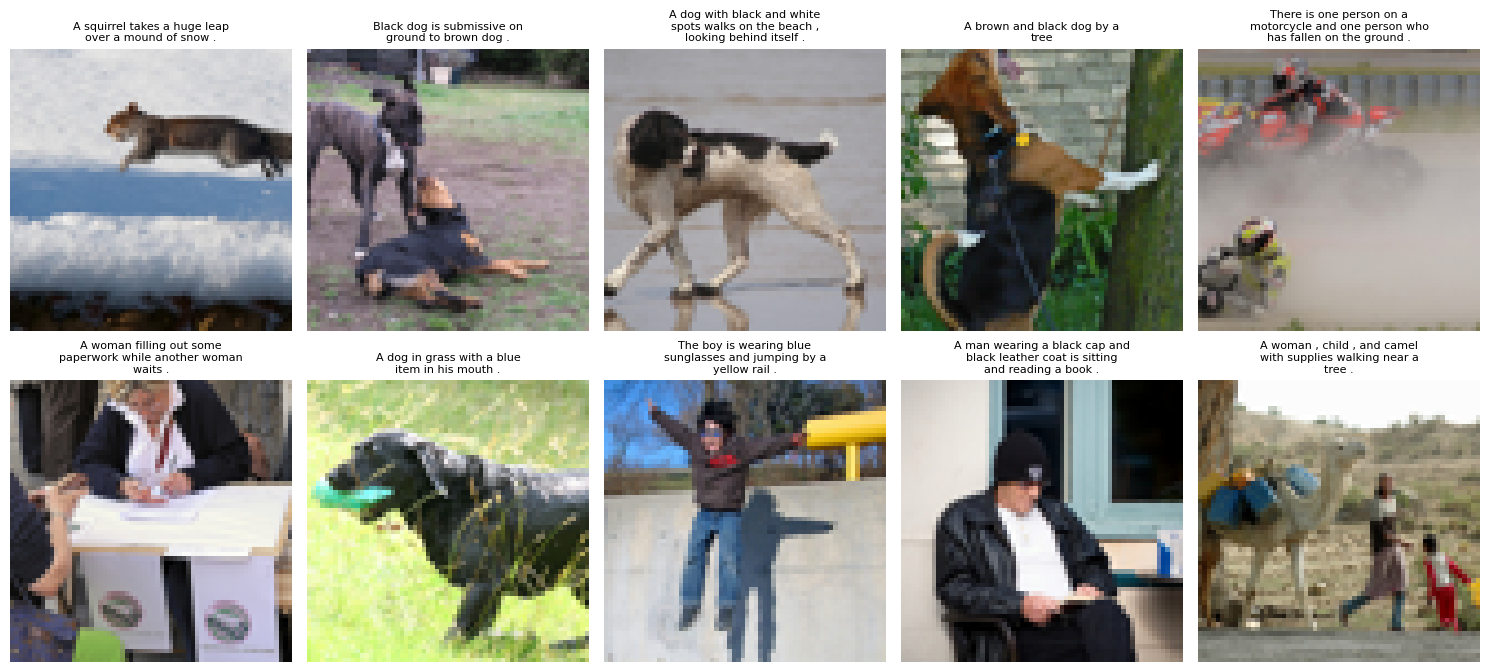

In [19]:
def visualize_dataset_samples(dataset):
    """Visualize some samples from our dataset"""

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))

    list_indices = np.random.randint(0, len(dataset), size=10)

    for i, idx in enumerate(list_indices):
        image, caption = dataset[idx]

        # Denormalize image
        img = image.permute(1, 2, 0)
        img = (img * 0.5 + 0.5).clamp(0, 1)

        ax = axes[i // 5, i % 5]
        ax.imshow(img)

        # Wrap long captions into multiple lines
        caption = textwrap.fill(caption, width=30)

        ax.set_title(
            caption,
            fontsize=8,
            pad=6
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Visualize dataset samples
visualize_dataset_samples(train_dataset)


**Question 3.1:** Why did we choose CIFAR-10 for this introductory lab?

**Question 3.2:** What are the advantages and limitations of using simple text descriptions?

---

### ■ **<a name="section4">4. Building the Diffusion Model</a>** [(&#8593;)](#content)

Now let's build our complete text-conditioned diffusion model.

In [20]:
class SimpleTextEncoder(nn.Module):
    """A simple frozen CLIP text encoder for our captions"""

    def __init__(self, model_name="openai/clip-vit-base-patch32", embed_dim=512):
        super(SimpleTextEncoder, self).__init__()

        # CLIP tokenizer
        self.tokenizer = CLIPTokenizer.from_pretrained(model_name)

        # Pretrained CLIP text encoder
        self.clip = CLIPTextModelWithProjection.from_pretrained(model_name)

        # Freeze CLIP
        self.clip.requires_grad_(False)

        self.out_proj = nn.Linear(512, embed_dim) if embed_dim != 512 else nn.Identity()

    def forward(self, captions):
        """
        Args:
            captions: List of text descriptions

        Returns:
            text_embeddings: [batch_size, 512]
        """

        # Tokenize captions
        tokens = self.tokenizer(
            captions,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors="pt"
        )

        # Move tokens to the same device as CLIP
        tokens = {
            key: value.to(self.clip.device)
            for key, value in tokens.items()
        }

        # Get frozen CLIP embeddings
        with torch.no_grad():
            text_embeddings = self.clip(
                input_ids=tokens["input_ids"],
                attention_mask=tokens["attention_mask"]
            ).text_embeds


        text_embeddings = self.out_proj(text_embeddings)

        return text_embeddings  # [batch_size, embed_dim]


# denoiser with text conditioning
class TextConditionedDiffusionModel(nn.Module):
    """Diffusion model with text conditioning"""

    def __init__(self, timesteps=1000, image_size=64, text_embed_dim=512):
        super(TextConditionedDiffusionModel, self).__init__()

        self.timesteps = timesteps
        self.image_size = image_size

        # Noise schedule
        self.betas = linear_beta_schedule(timesteps)
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

        # U-Net for denoising
        self.unet = SimpleUNet(in_channels=3 + text_embed_dim)

        # Timestep embedding
        self.timestep_embedding = nn.Sequential(
            nn.Linear(1, 128),
            nn.ReLU(),
            nn.Linear(128, text_embed_dim)
        )

    def forward(self, x, t, text_embeddings):
        """
        Forward pass of the diffusion model

        Args:
            x: Noisy images [batch_size, 3, height, width]
            t: Timesteps [batch_size]
            text_embeddings: Text embeddings [batch_size, embed_dim]
        """

        batch_size = x.shape[0]

        # Add timestep information
        t_embed = self.timestep_embedding(t.unsqueeze(1).float())  # [batch_size, text_embed_dim]

        # Combine timestep and text information
        conditioning = t_embed + text_embeddings

        # Reshape conditioning to spatial dimensions
        conditioning_spatial = (conditioning.unsqueeze(-1).unsqueeze(-1))

        conditioning_spatial = conditioning_spatial.repeat(1, 1, self.image_size, self.image_size)

        # Concatenate conditioning with noisy image
        x_conditioned = torch.cat([x, conditioning_spatial], dim=1)

        # Predict noise
        predicted_noise = self.unet(x_conditioned)

        return predicted_noise

    def sample_timesteps(self, batch_size):
        """Sample random timesteps for training"""
        return torch.randint(0, self.timesteps, (batch_size,))


# Let's test the model
def test_model():

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = TextConditionedDiffusionModel(image_size=IMAGE_SIZE, text_embed_dim=128).to(device)

    text_encoder = SimpleTextEncoder(embed_dim=128).to(device)

    batch_size = 4

    # Dummy inputs
    x = torch.randn(batch_size, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)

    t = torch.randint(0, 1000, (batch_size,)).to(device)

    # Real text descriptions instead of class labels
    captions = [
        "A brown dog is running through the grass.",
        "A child is playing with a ball outside.",
        "A man is riding a bicycle on the street.",
        "A group of people are standing on a beach."
    ]

    # Get CLIP text embeddings
    text_embeddings = text_encoder(captions)

    # Forward pass
    with torch.no_grad():
        predicted_noise = model(x, t, text_embeddings)

    print(f"Noisy image shape: {x.shape}")
    print(f"Text embeddings shape: {text_embeddings.shape}")
    print(f"Predicted noise shape: {predicted_noise.shape}")
    print("✓ Model forward pass successful!")


test_model()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_m

Noisy image shape: torch.Size([4, 3, 64, 64])
Text embeddings shape: torch.Size([4, 128])
Predicted noise shape: torch.Size([4, 3, 64, 64])
✓ Model forward pass successful!



**Question 4.1:** What is the role of the timestep embedding in the diffusion model?

* The timestep embedding tells the network (U-Net) the current noising step $t$. Since the noise level varies considerably between $t=0$ and $t=T$, it lets the model adapt its noise predictions while sharing the same weights across all steps of the process.

**Question 4.2:** How text conditioning is integrated to guide the image generation process?

* Text conditioning is integrated by first projecting the text description into a vector space with a text encoder (such as CLIP). This text representation is combined with the timestep embedding, then projected spatially to be concatenated with or injected into the U-Net feature maps, steering generation towards the described content.

---

### ■ **<a name="section5">5. Training the Model</a>** [(&#8593;)](#content)

Now let's train our diffusion model on the CIFAR-10 dataset with text captions.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_m

=== Diffusion Model Concepts Demonstration ===

1. Forward Diffusion Process:


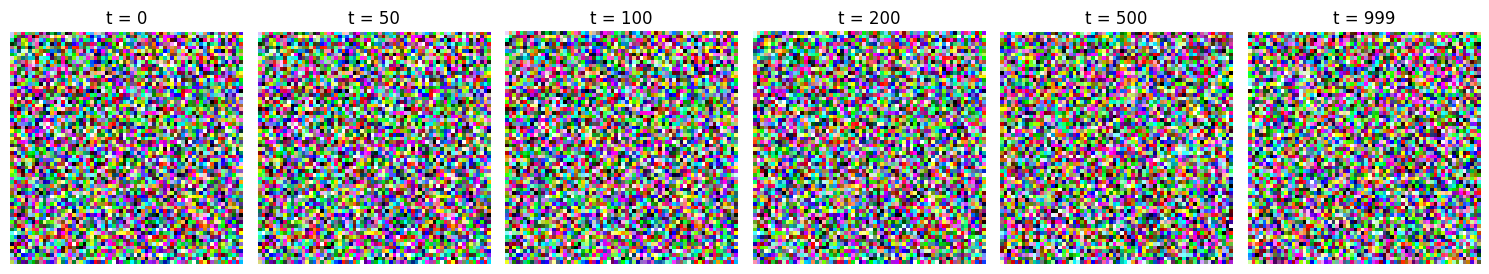


2. Model Architecture:


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_m

Total model parameters: 71,577,987

3. Dataset Samples:


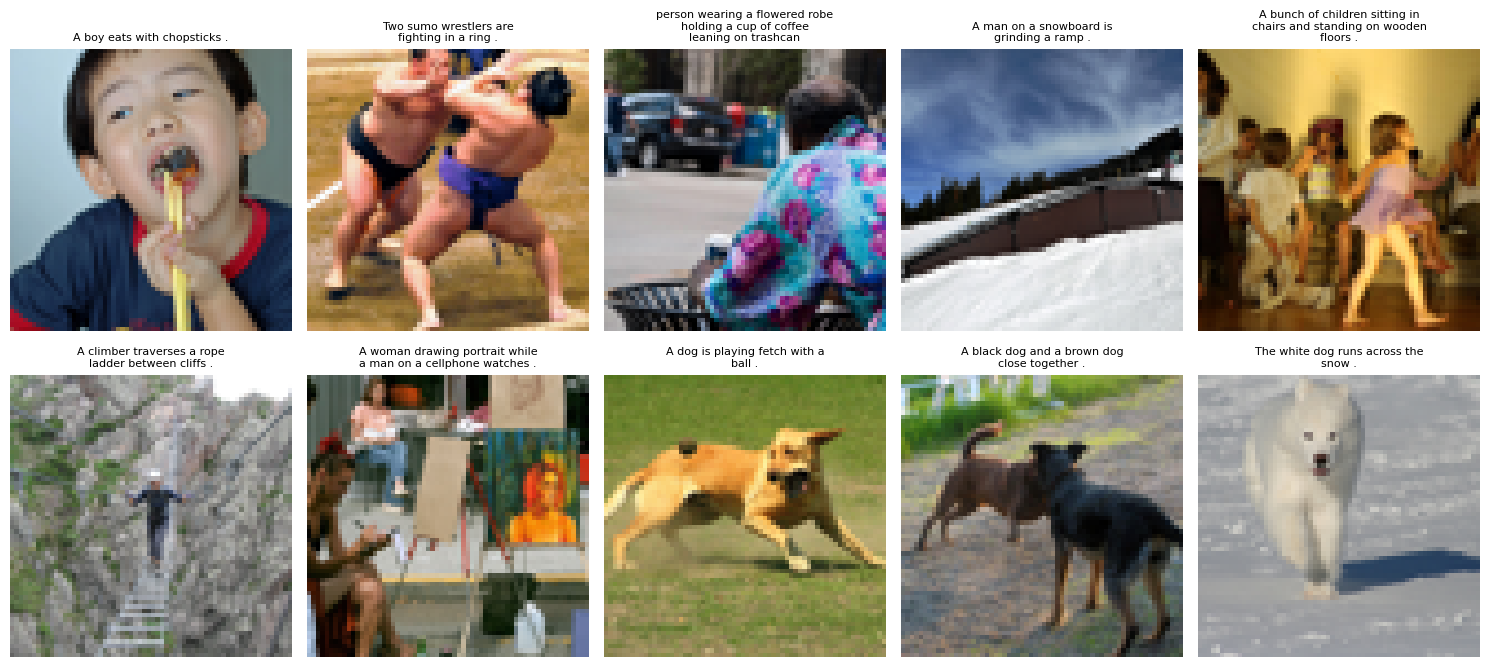


4. Training Process Explanation:
   - Sample random timestep t
   - Add noise to image: x_t = sqrt(alpha_t) * x_0 + sqrt(1-alpha_t) * epsilon
   - Predict the noise using U-Net
   - Compute MSE loss between predicted and actual noise
   - Backpropagate and update weights

5. Generation Process:
   - Start from random noise x_T ~ N(0, I)
   - For t = T to 1:
     - Predict noise: epsilon_theta = model(x_t, t, text_embedding)
     - Compute x_{t-1} using the reverse process
   - Final result: x_0 (generated image)


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters - reduced for quick training
TEXT_DIM = 128
batch_size = 16
learning_rate = 1e-4
epochs = 100  # Very few epochs for demonstration (you can train it for 1000 epochs or more !)
timesteps = 200  # Reduced timesteps for faster training (typically: 1000)

# Initialize model with reduced timesteps
model = TextConditionedDiffusionModel(timesteps=timesteps, image_size=IMAGE_SIZE, text_embed_dim=TEXT_DIM).to(device)
text_encoder = SimpleTextEncoder(embed_dim=TEXT_DIM).to(device)

# Optimizer and loss
optimizer = optim.Adam(list(model.parameters()) + list(text_encoder.parameters()), lr=learning_rate)
criterion = nn.MSELoss()

# Simplified training with proper error handling
def train_simple_diffusion_model():
    """Simplified training loop for our diffusion model"""
    print(f"Using device: {device}")

    # Training loop
    model.train()
    text_encoder.train()

    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch_idx, (images, captions) in enumerate(progress_bar):
            images = images.to(device)
            batch_size = images.shape[0]

            # Sample timesteps
            t = model.sample_timesteps(batch_size).to(device)

            # Sample noise
            noise = torch.randn_like(images)

            # Add noise to images (forward process)
            x_t, noise = forward_diffusion_sample(images, t, model.betas, device)

            # Get text embeddings
            text_embeddings = text_encoder(captions)

            # Predict noise
            predicted_noise = model(x_t, t, text_embeddings)

            # Calculate loss
            loss = criterion(predicted_noise, noise)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}, Average Loss: {avg_loss:.4f}")

        ## show a generated sample
        demo_generation(train_loader)

    # Plot training loss
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    # return model, text_encoder

# Let's also create a function to demonstrate the training concept without actual training
def demonstrate_diffusion_concepts():
    """Demonstrate diffusion concepts without full training"""

    print("=== Diffusion Model Concepts Demonstration ===")

    # 1. Show forward diffusion process
    print("\n1. Forward Diffusion Process:")
    visualize_forward_process()

    # 2. Show model architecture
    print("\n2. Model Architecture:")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TextConditionedDiffusionModel(timesteps=200).to(device)
    text_encoder = SimpleTextEncoder().to(device)

    total_params = sum(p.numel() for p in model.parameters()) + sum(p.numel() for p in text_encoder.parameters())
    print(f"Total model parameters: {total_params:,}")

    # 3. Show dataset samples
    print("\n3. Dataset Samples:")
    visualize_dataset_samples(train_dataset)

    # 4. Explain the training process
    print("\n4. Training Process Explanation:")
    print("   - Sample random timestep t")
    print("   - Add noise to image: x_t = sqrt(alpha_t) * x_0 + sqrt(1-alpha_t) * epsilon")
    print("   - Predict the noise using U-Net")
    print("   - Compute MSE loss between predicted and actual noise")
    print("   - Backpropagate and update weights")

    # 5. Show what a trained model could generate
    print("\n5. Generation Process:")
    print("   - Start from random noise x_T ~ N(0, I)")
    print("   - For t = T to 1:")
    print("     - Predict noise: epsilon_theta = model(x_t, t, text_embedding)")
    print("     - Compute x_{t-1} using the reverse process")
    print("   - Final result: x_0 (generated image)")

# Run the demonstration
demonstrate_diffusion_concepts()

## **Training Function**

Generating images from text...


Generating images: 200it [00:01, 168.14it/s]


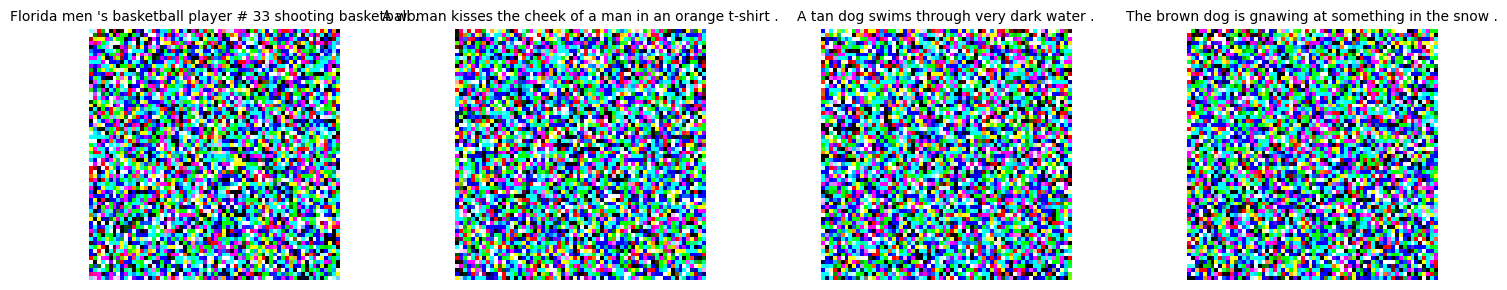

In [22]:
@torch.no_grad()
def generate_images(model, text_encoder, captions, num_images=4, image_size=64, device="cpu"):
    """
    Generate images from text captions using the trained diffusion model
    """
    model.eval()
    text_encoder.eval()

    # Convert captions to embeddings (simplified)
    # In practice, you would use a proper text tokenizer and encoder
    captions = captions[:num_images]
    text_embeddings = text_encoder(captions)

    # Start from random noise
    x = torch.randn(num_images, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)

    # Reverse diffusion process
    for t in tqdm(reversed(range(model.timesteps)), desc="Generating images"):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

        # Predict noise
        predicted_noise = model(x, t_batch, text_embeddings)

        # Get alpha and beta parameters
        alpha_t = model.alphas[t]
        alpha_t_cumprod = model.alphas_cumprod[t]
        beta_t = model.betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        # Reverse process step
        x = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alpha_t_cumprod)) * predicted_noise
        ) + torch.sqrt(beta_t) * noise

    # Denormalize images
    images = torch.clamp(x, -1, 1)
    images = (images + 1) / 2  # Scale to [0, 1]

    return images, captions

def visualize_generated_images(images, captions):
    """Visualize generated images with their captions"""
    fig, axes = plt.subplots(1, len(images), figsize=(15, 3))

    if len(images) == 1:
        axes = [axes]

    for i, (img, caption) in enumerate(zip(images, captions)):
        img = img.cpu().permute(1, 2, 0)
        axes[i].imshow(img)
        axes[i].set_title(caption, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Example generation (using a dummy model for demonstration)
def demo_generation(loader):

    # Example captions
    _, captions = next(iter(loader))

    print("Generating images from text...")
    generated_images, _ = generate_images(
        model, text_encoder, captions, num_images=4, device=device
    )

    visualize_generated_images(generated_images, captions)

# Run the demo
demo_generation(train_loader)

Using device: cuda


Epoch 1/100: 100%|██████████| 750/750 [00:53<00:00, 13.89it/s, Loss=0.1482]

Epoch 1, Average Loss: 0.4670


Generating images from text...


Generating images: 200it [00:01, 172.98it/s]


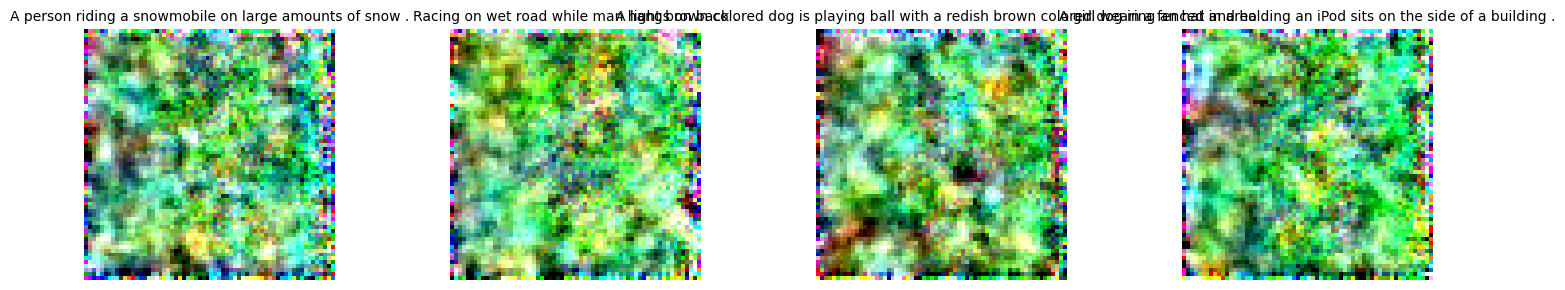

Epoch 2/100: 100%|██████████| 750/750 [00:46<00:00, 16.14it/s, Loss=0.2746]

Epoch 2, Average Loss: 0.3457


Generating images from text...


Generating images: 200it [00:01, 165.93it/s]


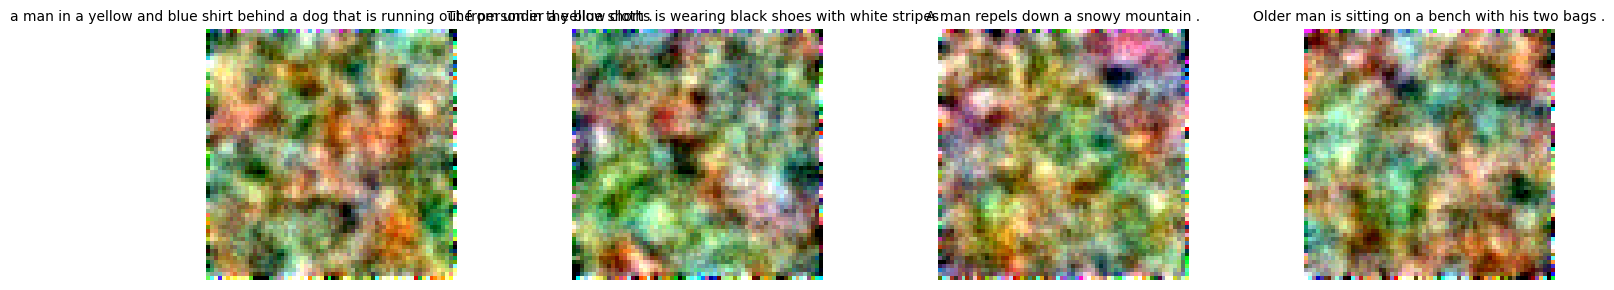

Epoch 3/100:  15%|█▍        | 112/750 [00:07<00:44, 14.41it/s, Loss=0.1319]


KeyboardInterrupt: 

In [23]:
## training function
train_simple_diffusion_model()


**Question 5.1:** Why do we use MSE loss between predicted noise and actual noise?

* To force the model to learn to remove as much noise as possible at each timestep.

**Question 5.2:** What happens if we use too many or too few timesteps in the diffusion process?

* The more timesteps, the longer training and sampling take.

---

### ■ **<a name="section6">6. Text-to-Image Generation</a>** [(&#8593;)](#content)

Now let's use our trained model to generate images from text descriptions!


Generating images from text...


Generating images: 200it [00:01, 154.67it/s]


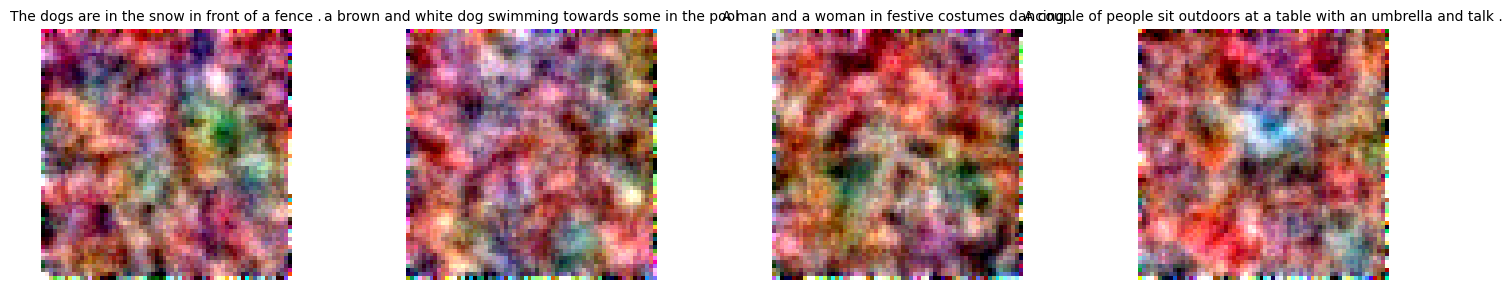

In [24]:
# Run the demo
demo_generation(test_loader)


**Question 6.1:** Why do we start the generation process from random noise?

**Question 6.2:** What is the role of the reverse process in image generation?

---

### ■ **<a name="section7">7. Model Evaluation</a>** [(&#8593;)](#content)

Let's evaluate our model and understand its limitations and potential improvements.


=== Diffusion Model Analysis ===

1. Forward Process:
   - Gradually adds noise to images
   - Controlled by noise schedule (beta)
   - Results in pure Gaussian noise after T steps

2. Reverse Process:
   - Learns to denoise images step by step
   - Uses U-Net architecture for noise prediction
   - Conditioned on timestep and text embeddings

3. Text Conditioning:
   - Guides image generation based on text prompts
   - Uses text embeddings from encoder
   - Can be improved with cross-attention mechanisms

4. Training Objective:
   - Predict the noise added during forward process
   - Simple MSE loss between predicted and actual noise
   - Enables stable training of diffusion models


Generating images: 200it [00:01, 139.35it/s]


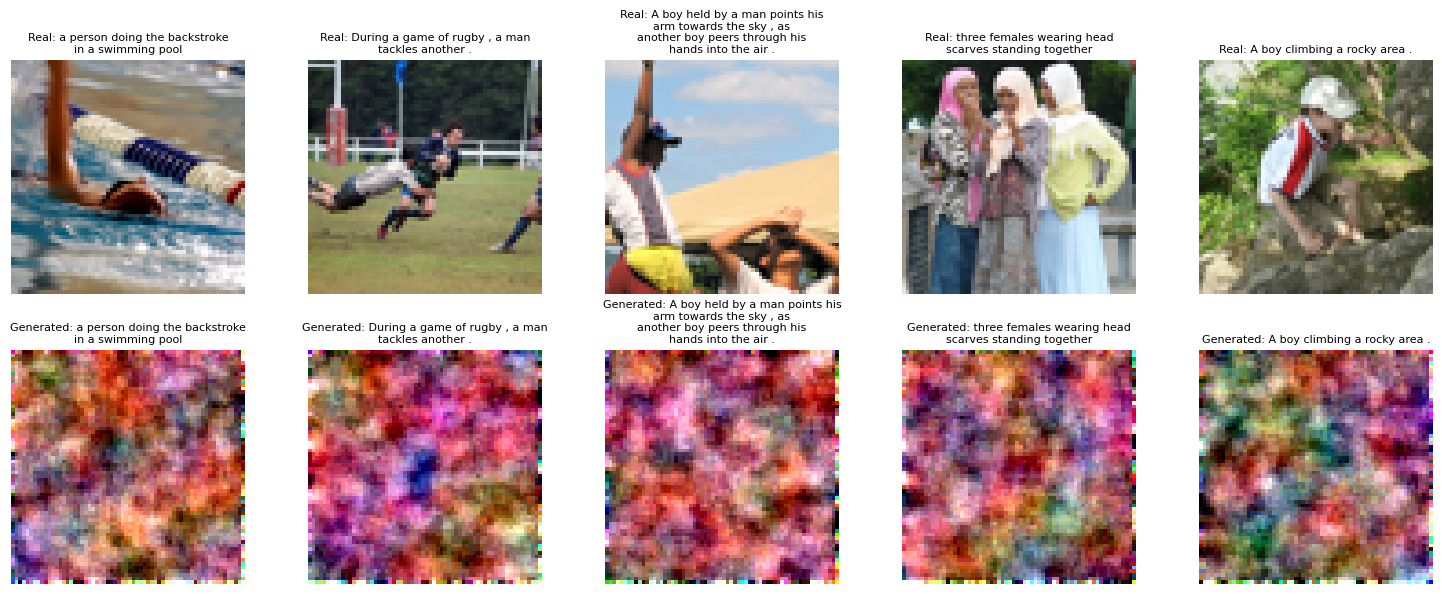

In [25]:
def evaluate_model_qualitatively(model, text_encoder, dataset, num_samples=5, device="cpu"):
    """Qualitative evaluation by comparing generated images with real ones"""
    model.eval()
    text_encoder.eval()

    # Get some real samples
    real_images, real_captions, real_labels = [], [], []
    indices = random.sample(range(len(dataset)), num_samples)

    for idx in indices:
        img, caption = dataset[idx]
        real_images.append(img)
        real_captions.append(caption)

    real_images = torch.stack(real_images).to(device)

    # Generate corresponding images
    generated_images, _ = generate_images(
        model, text_encoder, real_captions, num_images=num_samples, device=device
    )

    # Visualize comparison
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

    for i in range(num_samples):
        # Real image
        real_img = real_images[i].cpu().permute(1, 2, 0)
        real_img = (real_img * 0.5 + 0.5).clamp(0, 1)

        axes[0, i].imshow(real_img)
        real_caption = textwrap.fill(real_captions[i], width=30)
        axes[0, i].set_title(f"Real: {real_caption}", fontsize=8)
        axes[0, i].axis('off')

        # Generated image
        gen_img = generated_images[i].cpu().permute(1, 2, 0)
        axes[1, i].imshow(gen_img)
        axes[1, i].set_title(f"Generated: {real_caption}", fontsize=8)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

def analyze_training_components():
    """Analyze different components of the diffusion model"""

    print("=== Diffusion Model Analysis ===")
    print("\n1. Forward Process:")
    print("   - Gradually adds noise to images")
    print("   - Controlled by noise schedule (beta)")
    print("   - Results in pure Gaussian noise after T steps")

    print("\n2. Reverse Process:")
    print("   - Learns to denoise images step by step")
    print("   - Uses U-Net architecture for noise prediction")
    print("   - Conditioned on timestep and text embeddings")

    print("\n3. Text Conditioning:")
    print("   - Guides image generation based on text prompts")
    print("   - Uses text embeddings from encoder")
    print("   - Can be improved with cross-attention mechanisms")

    print("\n4. Training Objective:")
    print("   - Predict the noise added during forward process")
    print("   - Simple MSE loss between predicted and actual noise")
    print("   - Enables stable training of diffusion models")

# Run evaluation and analysis
analyze_training_components()

# Uncomment to run qualitative evaluation (requires trained model)
evaluate_model_qualitatively(model, text_encoder, test_dataset, device=device)


**Question 7.1:** What are the main limitations of our simple diffusion model?

**Question 7.2:** How could we improve the text conditioning mechanism?

# **Demo: Image Editing using InstructPix2Pix**

A demo notebook for [InstructPix2Pix](https://www.timothybrooks.com/instruct-pix2pix/) using [diffusers](https://github.com/huggingface/diffusers). InstructPix2Pix is fine-tuned stable diffusion model which allows you to edit images using language instructions.

<img src='https://instruct-pix2pix.timothybrooks.com/teaser.jpg'/>

In [1]:
# install package from github
!pip install -qqq git+https://github.com/huggingface/diffusers.git gradio transformers accelerate safetensors

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install -U "diffusers[torch]" transformers huggingface_hub httpx

#### To load a specific image, put its url bellow

In [3]:
%%capture
!wget https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.pngkey.com%2Fpng%2Fdetail%2F1-16373_dogs-png-jpg-royalty-free-library-dog-and.png&f=1&nofb=1&ipt=9253e872cdf38dc822598d18dc0ce8b3022a6d528e9f7870572f6996253efc34

In [4]:
import PIL
import requests
import torch

# Fully uninstall conflicting packages
!pip uninstall -y diffusers torchao
# Clean reinstall of diffusers and accelerate
!pip install -U diffusers accelerate transformers huggingface_hub httpx

from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler

model_id = "timbrooks/instruct-pix2pix"
pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(model_id, torch_dtype=torch.float16, revision="fp16", safety_checker=None)
pipe.to("cuda")
pipe.enable_attention_slicing()

Found existing installation: diffusers 0.41.0.dev0
Uninstalling diffusers-0.41.0.dev0:
  Successfully uninstalled diffusers-0.41.0.dev0
  Using cached diffusers-0.40.0-py3-none-any.whl.metadata (20 kB)
Using cached diffusers-0.40.0-py3-none-any.whl (5.9 MB)


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/pipeline_loading_utils.py:342: FutureWarning: You are loading the variant fp16 from timbrooks/instruct-pix2pix via `revision='fp16'`. This behavior is deprecated and will be removed in diffusers v1. One should use `variant='fp16'` instead. However, it appears that timbrooks/instruct-pix2pix currently does not have the required variant filenames in the 'main' branch. 
 The Diffusers team and community would be very grateful if you could open an issue: https://github.com/huggingface/diffusers/issues/new with the title 'timbrooks/instruct-pix2pix is missing fp16 files' so that the correct variant file can be added.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_instruct_pix2pix.StableDiffusionInstructPix2PixPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


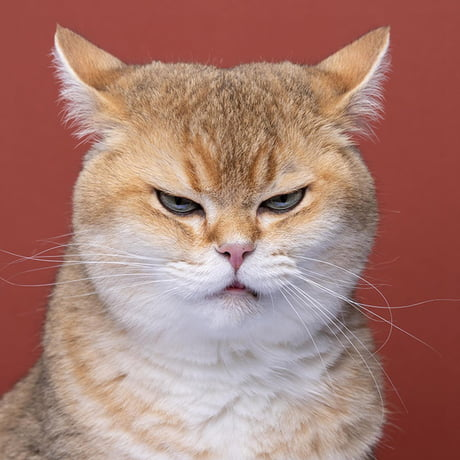

In [5]:
image = PIL.Image.open("./image.jpg")
image = PIL.ImageOps.exif_transpose(image)
image = image.convert("RGB")
image

Give him a leather jacket


  0%|          | 0/20 [00:00<?, ?it/s]

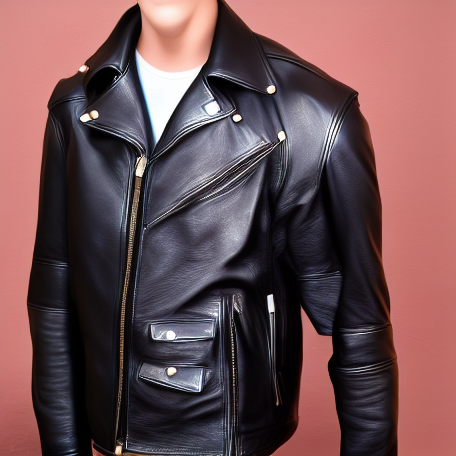

In [6]:
prompts = ["turn him into cyborg",
    "Make it a picasso painting",
    "as if it were by modigliani",
    "convert to a bronze statue",
    "Turn it into an anime.",
    "have it look like a graphic novel",
    "make him gain weight",
    "what would he look like bald?",
    "Have him smile",
    "Put him in a cocktail party.",
    "move him at the beach.",
    "add dramatic lighting",
    "Convert to black and white",
    "What if it were snowing?",
    "Give him a leather jacket",
    "Turn him into a cyborg!",
    "make him wear a beanie",
    ]
prompt = "move him at the beach."

import numpy as np
prompt = np.random.choice(prompts)
print(prompt)
pipe(prompt, image=image, num_inference_steps=20, image_guidance_scale=1).images[0]

  0%|          | 0/20 [00:00<?, ?it/s]

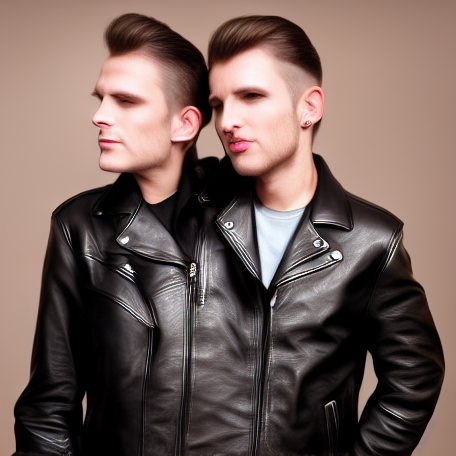

In [7]:
pipe(prompt, image=image, num_inference_steps=20, image_guidance_scale=1).images[0]